In [6]:
# imports
import math
# importing Qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
#import matplotlib
#import matplotlib.pyplot as plt
#plt.use('Agg')  # Use non-GUI backend

In [7]:
f = open("cnf_test1.txt")
info = f.readline().split(' ')
literals = int(info[0])
clausulas = int(info[1])

lines = [line.rstrip('\n') for line in f]

formula = []
for i in lines:
    l = i.split(' ')
    formula.append([int(l[0]),int(l[1]),int(l[2])])

In [8]:
n = literals + clausulas + 2 # Number of qubits in the circuit

In [9]:
def initialize_grover(qc, qubits):
    # Superposition
    for i in range(literals+1):
        qc.h(qubits[i])
        
    # State |-⟩
    qc.x(n-1)
    qc.h(n-1)
    
    return qc

In [10]:
qc = QuantumCircuit(n)

# Creation of each clause.
contador = 0
for c in formula:
    for i in range(3):
        if c[i] > 0:
            qc.x(abs(c[i])-1)
            
    qc.mcx(list([abs(c[0])-1,abs(c[1])-1,abs(c[2])-1]), literals+1+contador)  # multi-controlled-toffoli
    
    for i in range(3):
        if c[2-i] > 0:
            qc.x(abs(c[2-i])-1)
    
    contador+=1


# Checking of each clause
qc.x(literals) # Augmented space
for q in range(literals+1,n-1):
    qc.x(q)
    
qc.mcx(list(list([literals, *range(literals+1,n-1)])), n-1)

for q in range(literals+1,n-1):
    qc.x(q)
qc.x(literals) # Augmented space


# Creation of each clause (symmetry).    
contador -= 1
for c in reversed(formula):
    for i in range(3):
        if c[i] > 0:
            qc.x(abs(c[i])-1)
            
    qc.mcx(list([abs(c[0])-1,abs(c[1])-1,abs(c[2])-1]), literals+1+contador)
    
    for i in range(3):
        if c[2-i] > 0:
            qc.x(abs(c[2-i])-1)
    
    contador-=1

oracle = qc.to_gate()
oracle.name = "Oracle"
qc.draw()

┌───┐     ┌───┐          ┌───┐     ┌───┐┌───┐          ┌───┐     ┌───┐»
q_0: ┤ X ├──■──┤ X ├───────■──┤ X ├──■──┤ X ├┤ X ├───────■──┤ X ├──■──┤ X ├»
     ├───┤  │  ├───┤┌───┐  │  ├───┤  │  └───┘└───┘       │  ├───┤  │  ├───┤»
q_1: ┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├──■───────────────────■──┤ X ├──■──┤ X ├»
     ├───┤  │  ├───┤└───┘  │  └───┘  │                   │  └───┘  │  ├───┤»
q_2: ┤ X ├──■──┤ X ├───────■─────────■───────────────────■─────────■──┤ X ├»
     ├───┤  │  └───┘       │         │            ┌───┐  │         │  └───┘»
q_3: ┤ X ├──┼──────────────┼─────────┼─────────■──┤ X ├──┼─────────┼───────»
     └───┘┌─┴─┐┌───┐       │         │         │  ├───┤  │         │       »
q_4: ─────┤ X ├┤ X ├───────┼─────────┼─────────■──┤ X ├──┼─────────┼───────»
          └───┘└───┘     ┌─┴─┐┌───┐  │         │  ├───┤  │       ┌─┴─┐     »
q_5: ────────────────────┤ X ├┤ X ├──┼─────────■──┤ X ├──┼───────┤ X ├─────»
                         └───┘└───┘┌─┴─┐┌───┐  │  ├───┤┌─┴─┐     └───┘     »
q_6: ──────────────────────────────┤ X ├┤ X ├──■──┤ X ├┤ X ├───────────────»
                                   └───┘└───┘┌─┴─┐└───┘└───┘               »
q_7: ────────────────────────────────────────┤ X ├─────────────────────────»
                                             └───┘                         »
«               ┌───┐
«q_0: ───────■──┤ X ├
«     ┌───┐  │  ├───┤
«q_1: ┤ X ├──■──┤ X ├
«     └───┘  │  ├───┤
«q_2: ───────■──┤ X ├
«            │  └───┘
«q_3: ───────┼───────
«          ┌─┴─┐     
«q_4: ─────┤ X ├─────
«          └───┘     
«q_5: ───────────────
«                    
«q_6: ───────────────
«                    
«q_7: ───────────────
«

In [11]:
qc = QuantumCircuit(n)

for qubit in range(literals+1):
        qc.h(qubit)
        
for qubit in range(literals+1):
        qc.x(qubit)
        
# Equivalent Diffuser. It gives us the opposite result in Quantum counting, therefore M will be the number of no solutions at the end.
qc.mcx(list([i for i in range(literals+1)]), n-1)

########## Original Diffuser ##############################################################
#qc.mct(list([i for i in range(literals+1)]), literals+1)
#qc.x(literals+1)
#qc.cx(literals+1,n-1)
#qc.x(literals+1)
#qc.mct(list([i for i in range(literals+1)]), literals+1)
###########################################################################################

for qubit in range(literals+1):
        qc.x(qubit)
        
for qubit in range(literals+1):
        qc.h(qubit)

inversionMean = qc.to_gate()
inversionMean.name = "inversionMean"
qc.draw()

┌───┐┌───┐     ┌───┐┌───┐
q_0: ┤ H ├┤ X ├──■──┤ X ├┤ H ├
     ├───┤├───┤  │  ├───┤├───┤
q_1: ┤ H ├┤ X ├──■──┤ X ├┤ H ├
     ├───┤├───┤  │  ├───┤├───┤
q_2: ┤ H ├┤ X ├──■──┤ X ├┤ H ├
     ├───┤├───┤  │  ├───┤├───┤
q_3: ┤ H ├┤ X ├──■──┤ X ├┤ H ├
     └───┘└───┘  │  └───┘└───┘
q_4: ────────────┼────────────
                 │            
q_5: ────────────┼────────────
                 │            
q_6: ────────────┼────────────
               ┌─┴─┐          
q_7: ──────────┤ X ├──────────
               └───┘

In [12]:
grover_iteration = QuantumCircuit(n)

grover_iteration.append(oracle, list(range(n)))
grover_iteration.append(inversionMean, list(range(n)))

gi = grover_iteration.to_gate()
gi.label = "GroverI"
cgi = gi.control()

In [13]:
def qft(n):
    circuit = QuantumCircuit(n)
    
    def swap_registers(circuit, n):
        for qubit in range(n//2):
            circuit.swap(qubit, n-qubit-1)
        return circuit
    
    def qft_rotations(circuit, n):
        #Performs qft on the first n qubits in circuit (without swaps)
        if n == 0:
            return circuit
        n -= 1
        circuit.h(n)
        for qubit in range(n):
            circuit.cp(math.pi/2**(n-qubit), qubit, n)
        qft_rotations(circuit, n)
    
    qft_rotations(circuit, n)
    swap_registers(circuit, n)  # Comment this line if we use the 2 possible order of the QPE registers
    return circuit

In [14]:
t = literals+1  # Number of counting qubits.
qft_dagger = qft(t).to_gate().inverse()
qft_dagger.label = "QFT†"

In [15]:
qpe = QuantumCircuit(n+t, t) # Circuit with n+t qubits and t classical bits

# Superposition
for qubit in range(t+literals+1):
    qpe.h(qubit)

# State |-⟩
qpe.x(n+t-1)
qpe.h(n+t-1)
    
# Grover iterations
iterations = 1
for qubit in range(t):
    for i in range(iterations):
        qpe.append(cgi, [qubit] + [*range(t, n+t)])   # Using this line, uncomment the QFT swap.
        #qpe.append(cgrit, [(t-1)-qubit] + [*range(t, n+t)]) # Using this line, comment the QFT swap.

    iterations *= 2
    
# Application of QFT inverse to all counting qubits
qpe.append(qft_dagger, range(t))

# Measure the counting qubits
qpe.measure(range(t), range(t))

qpe.draw()

┌───┐                                                                 »
 q_0: ┤ H ├──────────■──────────────────────────────────────────────────────»
      ├───┤          │                                                      »
 q_1: ┤ H ├──────────┼───────────■───────────■──────────────────────────────»
      ├───┤          │           │           │                              »
 q_2: ┤ H ├──────────┼───────────┼───────────┼───────────■───────────■──────»
      ├───┤          │           │           │           │           │      »
 q_3: ┤ H ├──────────┼───────────┼───────────┼───────────┼───────────┼──────»
      ├───┤     ┌────┴─────┐┌────┴─────┐┌────┴─────┐┌────┴─────┐┌────┴─────┐»
 q_4: ┤ H ├─────┤0         ├┤0         ├┤0         ├┤0         ├┤0         ├»
      ├───┤     │          ││          ││          ││          ││          │»
 q_5: ┤ H ├─────┤1         ├┤1         ├┤1         ├┤1         ├┤1         ├»
      ├───┤     │          ││          ││          ││          ││          │»
 q_6: ┤ H ├─────┤2         ├┤2         ├┤2         ├┤2         ├┤2         ├»
      ├───┤     │          ││          ││          ││          ││          │»
 q_7: ┤ H ├─────┤3         ├┤3         ├┤3         ├┤3         ├┤3         ├»
      └───┘     │  GroverI ││  GroverI ││  GroverI ││  GroverI ││  GroverI │»
 q_8: ──────────┤4         ├┤4         ├┤4         ├┤4         ├┤4         ├»
                │          ││          ││          ││          ││          │»
 q_9: ──────────┤5         ├┤5         ├┤5         ├┤5         ├┤5         ├»
                │          ││          ││          ││          ││          │»
q_10: ──────────┤6         ├┤6         ├┤6         ├┤6         ├┤6         ├»
      ┌───┐┌───┐│          ││          ││          ││          ││          │»
q_11: ┤ X ├┤ H ├┤7         ├┤7         ├┤7         ├┤7         ├┤7         ├»
      └───┘└───┘└──────────┘└──────────┘└──────────┘└──────────┘└──────────┘»
 c: 4/══════════════════════════════════════════════════════════════════════»
                                                                            »
«                                                                              »
« q_0: ────────────────────────────────────────────────────────────────────────»
«                                                                              »
« q_1: ────────────────────────────────────────────────────────────────────────»
«                                                                              »
« q_2: ─────■───────────■──────────────────────────────────────────────────────»
«           │           │                                                      »
« q_3: ─────┼───────────┼───────────■───────────■───────────■───────────■──────»
«      ┌────┴─────┐┌────┴─────┐┌────┴─────┐┌────┴─────┐┌────┴─────┐┌────┴─────┐»
« q_4: ┤0         ├┤0         ├┤0         ├┤0         ├┤0         ├┤0         ├»
«      │          ││          ││          ││          ││          ││          │»
« q_5: ┤1         ├┤1         ├┤1         ├┤1         ├┤1         ├┤1         ├»
«      │          ││          ││          ││          ││          ││          │»
« q_6: ┤2         ├┤2         ├┤2         ├┤2         ├┤2         ├┤2         ├»
«      │          ││          ││          ││          ││          ││          │»
« q_7: ┤3         ├┤3         ├┤3         ├┤3         ├┤3         ├┤3         ├»
«      │  GroverI ││  GroverI ││  GroverI ││  GroverI ││  GroverI ││  GroverI │»
« q_8: ┤4         ├┤4         ├┤4         ├┤4         ├┤4         ├┤4         ├»
«      │          ││          ││          ││          ││          ││          │»
« q_9: ┤5         ├┤5         ├┤5         ├┤5         ├┤5         ├┤5         ├»
«      │          ││          ││          ││          ││          ││          │»
«q_10: ┤6         ├┤6         ├┤6         ├┤6         ├┤6         ├┤6         ├»
«      │          ││          ││          ││          ││          ││          │»
«q_11: ┤7         ├┤7         ├┤7    

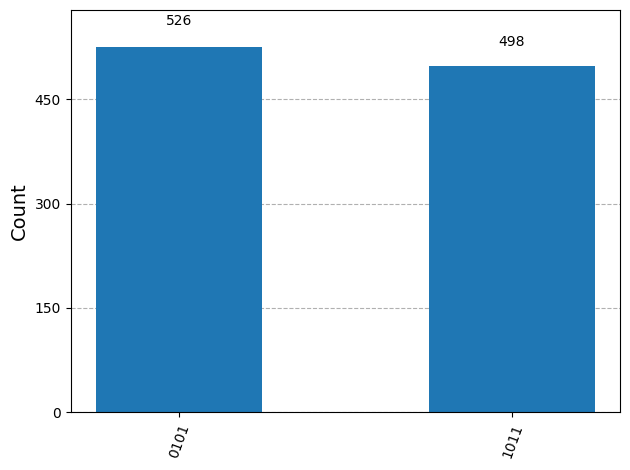

In [16]:
aer_sim = Aer.get_backend('aer_simulator')

# Transpile the circuit for the simulator
transpiled_qpe = transpile(qpe, aer_sim)

# Run the simulation
job = aer_sim.run(transpiled_qpe)
result = job.result()

# Get and plot the counts
hist = result.get_counts()
plot_histogram(hist)

In [17]:
measured_str = max(hist, key=hist.get)

measured_int = int(measured_str,2)
print(measured_str)
print("Register Output = %i" % measured_int)

theta = (measured_int/(2**t))*math.pi*2
print("Theta = %.5f" % theta)

0101
Register Output = 5
Theta = 1.96350


In [18]:
N = 2**(literals+1)
M = N * (math.sin(theta/2)**2)
M = N-M # Diffuser faster only
print(N,M)
print("No. of Solutions = %.1f" % M)

16 4.938532541079281
No. of Solutions = 4.9


In [19]:
# Upper bound error for the number of solutions
m = t - 1
err = (math.sqrt(2*M*N) + N/(2**(m+1)))*(2**(-m))
print("Error < %.2f" % err)

Error < 1.70


### Grover's Algorithm

In [20]:
rounds = math.pi/4.0*math.sqrt(N/M)
print("Result:",rounds)
print("Iterations R ≤",math.ceil(rounds))

if math.floor(rounds) == 0:
    rounds = round(rounds)
else:
    rounds = math.floor(rounds)

print("Iterations chosen:", rounds)

Result: 1.4136793455054262
Iterations R ≤ 2
Iterations chosen: 1


In [21]:
grover_circuit = QuantumCircuit(n,literals+1)

grover_circuit = initialize_grover(grover_circuit, list(range(n)))
for i in range(rounds):
    grover_circuit.append(oracle, list(range(n)))
    grover_circuit.append(inversionMean, list(range(n)))

for i in range(literals+1):
    grover_circuit.measure([i],[i])

grover_circuit.draw()

┌───┐     ┌─────────┐┌────────────────┐┌─┐         
q_0: ┤ H ├─────┤0        ├┤0               ├┤M├─────────
     ├───┤     │         ││                │└╥┘┌─┐      
q_1: ┤ H ├─────┤1        ├┤1               ├─╫─┤M├──────
     ├───┤     │         ││                │ ║ └╥┘┌─┐   
q_2: ┤ H ├─────┤2        ├┤2               ├─╫──╫─┤M├───
     ├───┤     │         ││                │ ║  ║ └╥┘┌─┐
q_3: ┤ H ├─────┤3        ├┤3               ├─╫──╫──╫─┤M├
     └───┘     │  Oracle ││  inversionMean │ ║  ║  ║ └╥┘
q_4: ──────────┤4        ├┤4               ├─╫──╫──╫──╫─
               │         ││                │ ║  ║  ║  ║ 
q_5: ──────────┤5        ├┤5               ├─╫──╫──╫──╫─
               │         ││                │ ║  ║  ║  ║ 
q_6: ──────────┤6        ├┤6               ├─╫──╫──╫──╫─
     ┌───┐┌───┐│         ││                │ ║  ║  ║  ║ 
q_7: ┤ X ├┤ H ├┤7        ├┤7               ├─╫──╫──╫──╫─
     └───┘└───┘└─────────┘└────────────────┘ ║  ║  ║  ║ 
c: 4/════════════════════════════════════════╩══╩══╩══╩═
                                             0  1  2  3


Total count: {'0011': 210, '1010': 4, '0001': 207, '0100': 180, '0111': 181, '0010': 212, '1111': 5, '1000': 5, '0101': 2, '1110': 3, '1101': 2, '1001': 5, '1100': 3, '1011': 3, '0000': 1, '0110': 1}


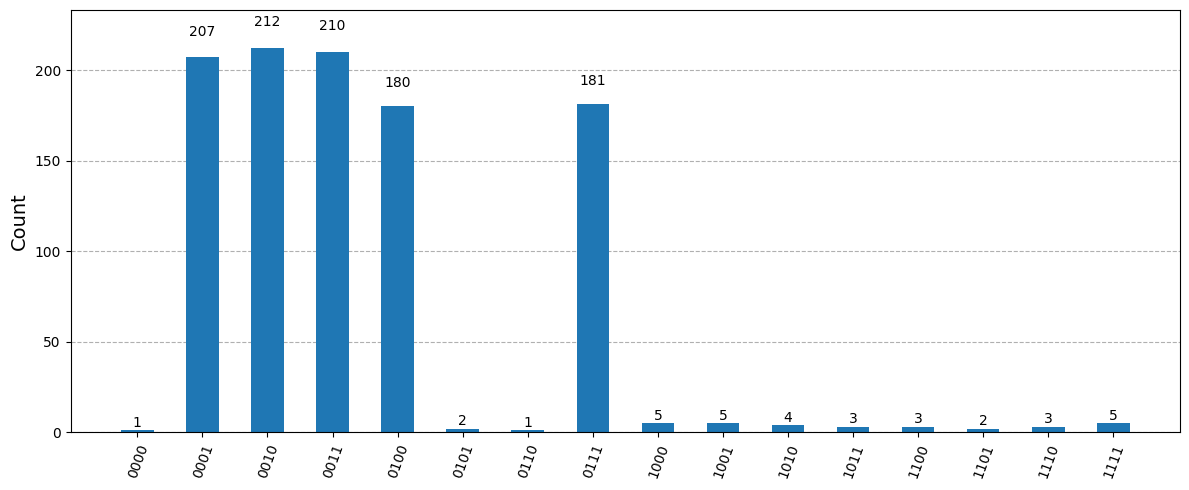

In [22]:

aer_sim = Aer.get_backend('aer_simulator')

# Transpile the circuit for the simulator
transpiled_grover_circuit = transpile(grover_circuit, aer_sim)

# Run the simulation
job = aer_sim.run(transpiled_grover_circuit, shots=1024)
results = job.result()

# Get and plot the counts
counts = results.get_counts()
print("\nTotal count:", counts)
plot_histogram(counts, figsize=(12,5))

In [23]:
#import matplotlib.pyplot as plt
plt=plot_histogram(counts, figsize=(12,5))
plt.savefig("output.png")